> ASR API 更新：代码已改用 `ClusterSpace(..., asr=True)` 初始化自由坐标。
> 当前保留的执行输出来自改动前的历史运行，尚未按此接口重新生成；不能作为新路线验收结果。


# Si：有限差分与外推

`FiniteDifference` 是"一阶一对象"的位移实验接口：给定阶数与位移幅度，它生成
有序位移结构，交给任意 ASE calculator 计算力，再把力重构为该阶的力常数。

本教程在硅上完整走一遍这条流水线，calculator 用 ASE 自带的
**Erhart–Albe Si-II Tersoff 势**，因此整个 notebook 无需任何外部程序即可重跑：

- FC2 与 FC3 分开建 `FiniteDifference` 对象（接口契约：一阶一对象）；
- 每阶用多步位移 $(0.005, 0.01, 0.015)$ Å 做**多步外推**，压制高阶位移项的影响；
- 拟合结果做 ASR 投影，导出 phonopy/phono3py HDF5；
- 用 Harmonic 画声子谱，用 phono3py RTA 算 300 K 热导率。

用 DFT 力做同一件事的**VASP sow/reap 工作流**在文末以文字说明——它不在
notebook 里执行，因为 VASP 计算无法在这里复现。

In [1]:
from pathlib import Path
import tempfile
import warnings

import matplotlib.pyplot as plt
import numpy as np
from ase.calculators.tersoff import Tersoff
from ase.io import read
from phonopy.structure.cells import PrimitiveMatrixAutoDefaultWarning

import mlfcs
from mlfcs import ClusterMap, ClusterSpace, FiniteDifference

# phonopy v4 对 primitive_matrix="auto" 的默认值变更提示与本教程无关。
warnings.filterwarnings("ignore", category=PrimitiveMatrixAutoDefaultWarning)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

DATA = Path("data") / "si"
POTENTIAL_FILE = DATA / "Erhart-Albe-Si-II.tersoff"
SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-si-fd-"))
DISPS = (0.005, 0.01, 0.015)
# 正的绝对截断(Å)，对应远程 SI 负壳语义 {2: -7, 3: -6} 的解析值；
# 壳距可用 mlfcs.tools.EstimateCutoff.get(n) 查询（第 n/n+1 壳中点）。
CUTOFFS = {2: 7.418817376, 3: 6.900754996}
MAX_BODY_ORDERS = {2: 2, 3: 3}
print(f"mlfcs {mlfcs.__version__}")

mlfcs 4.6.0


## 模型与映射

原胞（2 原子 FCC 金刚石原胞）与 $4\times4\times4$、128 原子参考超胞取自随数据
入库的 `POSCAR`/`SPOSCAR`（phonopy 生成，原子顺序与远程 SI 案例严格一致）。
`ClusterMap` 不给 `supercell_matrix` 时会从超胞原子自行推断——这正是显式几何
契约的做法。

In [2]:
from ase.io import read

primitive = read(DATA / "POSCAR")
supercell = read(DATA / "SPOSCAR")
print(f"primitive: {len(primitive)} atoms, supercell: {len(supercell)} atoms")

primitive: 2 atoms, supercell: 128 atoms


In [3]:
space = ClusterSpace(primitive, cutoffs=CUTOFFS, max_body_orders=MAX_BODY_ORDERS, asr=True)
mapping = ClusterMap(space, supercell)
print(f"orders={space.orders}, orbits and parameters per order:")
for order in space.orders:
    block = space.block(order)
    print(
        f"  FC{order}: orbits={block.orbits.stop - block.orbits.start}, "
        f"parameters={block.parameters.stop - block.parameters.start}"
    )


2026-10-07 16:54:53 INFO mlfcs.cluster_space.construction: Cluster-space construction started: primitive_atoms=2 orders=(2, 3) symprec=1e-05


2026-10-07 16:54:53 INFO mlfcs.cluster_space.construction: Primitive symmetry ready: operations=48 symbol=Fd-3m


2026-10-07 16:54:53 INFO mlfcs.cluster_space.construction: Order construction started: order=2 cutoff_angstrom=7.418817376 max_body_order=2


2026-10-07 16:54:53 INFO mlfcs.cluster_space.construction: Candidates ready: order=2 candidates=174


2026-10-07 16:54:53 INFO mlfcs.cluster_space.construction: Order complete: order=2 orbits=9 parameters=28 elapsed_s=0.21


...

2026-10-07 16:54:53 INFO mlfcs.mapping.cluster_map: Mapping started: primitive_atoms=2 matrix_source=inferred


2026-10-07 16:54:53 INFO mlfcs.mapping.cluster_map: Supercell matrix inferred: [[4, 0, 0], [0, 4, 0], [0, 0, 4]]


2026-10-07 16:54:53 INFO mlfcs.mapping.cluster_map: Supercell validated: supercell_atoms=128 matrix=[[4, 0, 0], [0, 4, 0], [0, 0, 4]]


2026-10-07 16:54:53 INFO mlfcs.mapping.cluster_map: Mapping complete: orbits=41 images=4820 elapsed_s=0.03


orders=(2, 3), orbits and parameters per order:
  FC2: orbits=9, parameters=28
  FC3: orbits=32, parameters=471


## 有限差分与重构

每阶的流程：

1. `FiniteDifference(mapping, order=n, disps=DISPS)` 生成位移实验；
2. 在外部使用 Tersoff calculator 计算位移结构的力，并通过 `ForceDataset` 收集；
3. `reconstruct(dataset)` 从有序数据集重构该阶力常数；
4. `ClusterSpace(..., asr=True)` 提前准备 ASR 自由坐标；外推后在该空间重建力常数。

In [4]:
from ase.calculators.singlepoint import SinglePointCalculator
from mlfcs import ForceDataset
calculator = Tersoff.from_lammps(POTENTIAL_FILE)
models = {}

for order in (2, 3):
    calculation = FiniteDifference(mapping, order=order, disps=DISPS)
    evaluated = []
    for atoms in calculation.displacements():
        atoms.calc = calculator
        forces = atoms.get_forces()
        atoms.calc = SinglePointCalculator(atoms, forces=forces)
        evaluated.append(atoms)
    data = ForceDataset(mapping, evaluated)
    model = calculation.reconstruct(data)
    models[order] = model
    print(
        f"FC{order}: steps={DISPS} Å, configurations={calculation.n_configurations}, "
        f"parameters={len(model.coefficients[order])}, "
        f"acoustic free parameters={space.acoustic_coordinates(order).dimension}"
    )

2026-10-07 16:54:53 INFO mlfcs.mapping.cluster_map: Folded rank started: order=2


2026-10-07 16:54:53 INFO mlfcs.mapping.cluster_map: Folded rank complete: parameters=28 rank=28 nullity=0 aliases=0 elapsed_s=0.00


2026-10-07 16:54:53 INFO mlfcs.finite_difference.sampling: Prepared FC2 finite difference: 18 configurations at displacements 0.005, 0.01, 0.015 Å


2026-10-07 16:54:57 INFO mlfcs.finite_difference.sampling: Finite-difference reconstruction started: order=2 configurations=18 steps_angstrom=(0.005, 0.01, 0.015)


2026-10-07 16:54:57 INFO mlfcs.finite_difference.sampling: Finite-difference reconstruction complete: order=2 parameters=28 elapsed_s=0.00


...

2026-10-07 16:56:06 INFO mlfcs.finite_difference.sampling: Finite-difference reconstruction complete: order=3 parameters=471 elapsed_s=0.00


2026-10-07 16:56:06 INFO mlfcs.force_constants.asr: ASR projection started: orders=(3,) rtol=1e-10


2026-10-07 16:56:06 INFO mlfcs.force_constants.asr: ASR order complete: order=3 equations=3834 iterations=0 relative_before=2.53654e-13 relative_after=2.53654e-13 correction_norm=0


2026-10-07 16:56:06 INFO mlfcs.force_constants.asr: ASR projection complete: orders=(3,) elapsed_s=0.02


FC3: steps=(0.005, 0.01, 0.015) Å, configurations=408, parameters=471, ASR relative residual=2.537e-13 -> 2.537e-13


## 导出

`ForceConstants.write` 支持多种外部格式。FC2 导出为 phonopy HDF5，FC3 导出为
phono3py HDF5——这正是下一步声子谱与热导率要消费的格式。

In [5]:
fc2_path = SCRATCH / "fc2-extrapolated.hdf5"
fc3_path = SCRATCH / "fc3-extrapolated.hdf5"
models[2].write(fc2_path, mapping, format="phonopy", storage="hdf5", order=2)
models[3].write(fc3_path, mapping, format="phono3py", storage="hdf5", order=3)
print(f"fc2 -> {fc2_path}")
print(f"fc3 -> {fc3_path}")

2026-10-07 16:56:06 INFO mlfcs.force_constants.formats: Export started: path=/tmp/mlfcs-si-fd-_hmo70n6/fc2-extrapolated.hdf5 format=phonopy order=2 storage=hdf5 threshold=1e-08


2026-10-07 16:56:06 INFO mlfcs.force_constants.formats: Export complete: path=/tmp/mlfcs-si-fd-_hmo70n6/fc2-extrapolated.hdf5 format=phonopy order=2 elapsed_s=0.24


2026-10-07 16:56:06 INFO mlfcs.force_constants.formats: Export started: path=/tmp/mlfcs-si-fd-_hmo70n6/fc3-extrapolated.hdf5 format=phono3py order=3 storage=hdf5 threshold=1e-08


2026-10-07 16:56:16 INFO mlfcs.force_constants.formats: Export complete: path=/tmp/mlfcs-si-fd-_hmo70n6/fc3-extrapolated.hdf5 format=phono3py order=3 elapsed_s=9.75


fc2 -> /tmp/mlfcs-si-fd-_hmo70n6/fc2-extrapolated.hdf5
fc3 -> /tmp/mlfcs-si-fd-_hmo70n6/fc3-extrapolated.hdf5


## 声子谱

直接用 `Harmonic(models[2]).run_band_path()` 计算参数化 FC2 的声子谱，不需要先写出再读回。
自动路径由 ASE 根据模型原胞晶胞生成，频率单位为 THz。
前面导出的 FC2/FC3 文件仍交给下一节的 phono3py 计算热导率；以原参考超胞作为
PhonopyAtoms unitcell、超胞矩阵取单位阵，保持文件中的原子顺序。

2026-10-07 16:56:16 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=2


2026-10-07 16:56:16 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=174 elapsed_s=0.00


2026-10-07 16:56:16 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=200 modes_per_q=6 imaginary_modes=0 range=[3.6014485e-07, 18.050033] THz elapsed=0.00 s


path: GXWKGLUWLK,UX, qpoints: 200


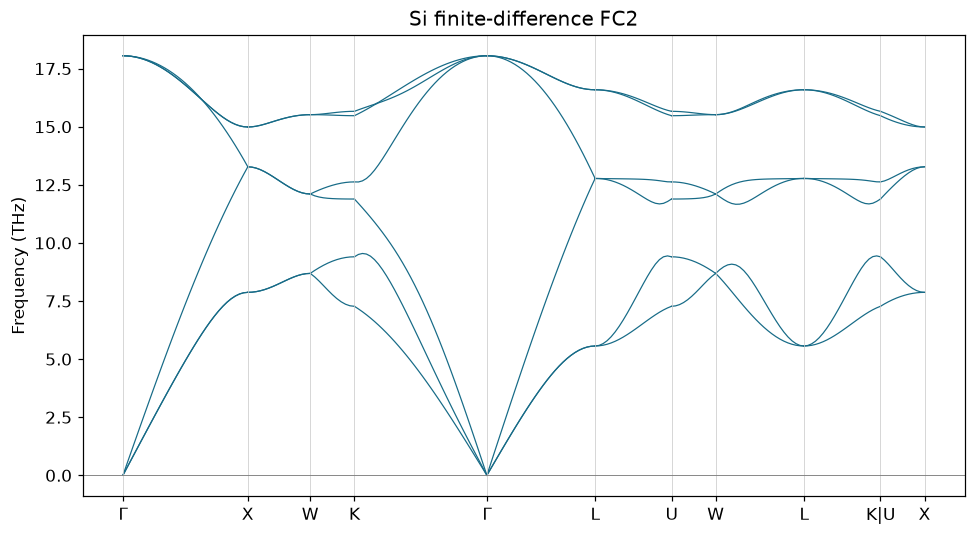

In [6]:
from mlfcs.phonon import Harmonic
from phono3py.file_IO import read_fc2_from_hdf5
from phonopy.structure.atoms import PhonopyAtoms

# The exported FC2/FC3 files and this atom order are used by phono3py below.
unitcell = PhonopyAtoms(
    symbols=supercell.get_chemical_symbols(),
    cell=supercell.cell.array,
    scaled_positions=supercell.get_scaled_positions(),
    masses=supercell.get_masses(),
)
bands = Harmonic(models[2]).run_band_path(npoints=200)
print(f"path: {bands.path}, qpoints: {len(bands.qpoints)}")

fig, axis = plt.subplots(figsize=(9, 5))
for segment in bands.segments:
    axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color="#176b87", lw=0.8)
axis.set_xticks(bands.tick_positions, bands.tick_labels)
for tick in bands.tick_positions:
    axis.axvline(tick, color="0.8", lw=0.5)
axis.axhline(0.0, color="0.5", lw=0.6)
axis.set_ylabel("Frequency (THz)")
axis.set_title("Si finite-difference FC2")
fig.tight_layout()
plt.show()

## 热导率（phono3py RTA）

装载 FC2/FC3 HDF5，在 $10\times10\times10$ q 网格上跑 300 K 的 RTA 输运，
打开同位素散射。硅 Tersoff 模型的热导率量级在几十到上百 W/(m·K)，远高于实验值
的量级修正请参考文献——这里关注的是流水线本身。

In [7]:
from phono3py import Phono3py
from phono3py.file_IO import read_fc3_from_hdf5

MESH = (10, 10, 10)
TEMPERATURES = (300,)

ph3 = Phono3py(unitcell, np.eye(3, dtype=int), primitive_matrix="auto", log_level=0)
p2s_map = np.asarray(ph3.phonon_primitive.p2s_map, dtype=int)
ph3.fc2 = read_fc2_from_hdf5(str(fc2_path))[p2s_map]
ph3.fc3 = read_fc3_from_hdf5(str(fc3_path))[p2s_map]
ph3.mesh_numbers = MESH
ph3.init_phph_interaction()
ph3.run_thermal_conductivity(
    temperatures=TEMPERATURES,
    is_isotope=True,
    write_kappa=False,
    log_level=0,
)
kappa = np.asarray(ph3.thermal_conductivity.kappa).reshape(-1, 6)
print(f"temperatures: {TEMPERATURES} K")
print(f"kappa_xx = {kappa[0, 0]:.3f} W/(m·K)")

temperatures: (300,) K
kappa_xx = 237.221 W/(m·K)


## 附：VASP sow/reap 工作流

如果力必须来自 DFT（VASP），`FiniteDifference` 的"生成位移—外部求值—重构"
循环变成一个 sow/reap 工作流（原 `SI/finite-difference-fc2` 案例，截断 6 Å、
单步位移 0.01 Å）：

1. **sow**：`fd.displacements()` 依次写出 `POSCAR-000 … POSCAR-00N`，把每个
   位移结构提交为一个独立的 VASP 任务（原案例用 6 个作业）；
2. **外部求值**：VASP 完成后，`reap` 从 `structures/job00*/vasprun.xml` 读取
   最后一步离子构型的力，用 `SinglePointCalculator` 挂回结构；
3. **reap**：`fd.reconstruct(ForceDataset(mapping, structures))` 按原采样顺序重构 FC2，不核对帧是否重排，
   初始化 `asr=True` 的 ASR 自由坐标重建，`model.write(..., format="phonopy",
   storage="text")` 输出 `fc2-phonopy.txt`。

关键契约：`reap` 会核对收到的结构数量与 `fd.n_configurations` 一致、且顺序与
sow 时的位移顺序逐位对应——这是有序位移接口的核心保证。这个循环无法在
notebook 里复现（需要 VASP 可执行文件与输入卡片），但其每一步的 Python 侧
代码与上面 Tersoff 流水线逐行同构。

## 小结

- `FiniteDifference` 一阶一对象；`disps` 接受多步幅度做外推；
- 位移采样与 `ForceDataset` 之间使用任何 ASE calculator 或外部程序计算力
  产出的存储力；
- 导出格式覆盖 phonopy（FC2）与 phono3py（FC3），下游声子谱与输运计算直接
  消费这些文件。